# Проект. Промышленность

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Задача — построить модель, которая будет её предсказывать.

Заказчик хочет использовать разработанную модель для имитации технологического процесса. Ниже расскажем о деталях этого процесса. Их важно знать, прежде чем генерировать новые признаки.

**Описание этапа обработки**

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша.

Из сплава выводится сера (этот процесс — десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (от англ. tribe — «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.

Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (от англ. slab — «плита»).

**Описание данных**

Данные состоят из нескольких файлов, полученных из разных источников:

- `data_arc_new.csv` — данные об электродах;
- `data_bulk_new.csv` — данные о подаче сыпучих материалов (объём);
- `data_bulk_time_new.csv` — данные о подаче сыпучих материалов (время);
- `data_gas_new.csv` — данные о продувке сплава газом;
- `data_temp_new.csv` — результаты измерения температуры;
- `data_wire_new.csv` — данные о проволочных материалах (объём);
- `data_wire_time_new.csv` — данные о проволочных материалах (время).

**Файл `data_arc_new.csv`**

- `key` — номер партии;
- `Начало нагрева дугой` — время начала нагрева;
- `Конец нагрева дугой` — время окончания нагрева;
- `Активная мощность` — значение активной мощности;
- `Реактивная мощность` — значение реактивной мощности.

**Файл `data_bulk_new.csv`**

- `key` — номер партии;
- `Bulk 1` … `Bulk 15` — объём подаваемого материала.

**Файл `data_bulk_time_new.csv`**

- `key` — номер партии;
- `Bulk 1` … `Bulk 15` — время подачи материала.

**Файл `data_gas_new.csv`**

- `key` — номер партии;
- `Газ 1` — объём подаваемого газа.

**Файл `data_temp_new.csv`**

- `key` — номер партии;
- `Время замера` — время замера;
- `Температура` — значение температуры.

**Файл `data_wire_new.csv`**

- `key` — номер партии;
- `Wire 1` … `Wire 9` — объём подаваемых проволочных материалов.

**Файл `data_wire_time_new.csv`**

- `key` — номер партии;
- `Wire 1` … `Wire 9` — время подачи проволочных материалов.

Во всех файлах столбец `key` содержит номер партии. В файлах может быть несколько строк с одинаковым значением `key`: они соответствуют разным итерациям обработки.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
try:
    import phik
except:
    !pip install phik -q
    import phik

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline

RANDOM_STATE = 310326

## Загрузка данных

In [53]:
data_arc = pd.read_csv('data_arc_new.csv')
data_bulk_volume = pd.read_csv('data_bulk_new.csv')
data_bulk_time = pd.read_csv('data_bulk_time_new.csv')
data_gas = pd.read_csv('data_gas_new.csv')
data_temp = pd.read_csv('data_temp_new.csv')
data_wire_volume = pd.read_csv('data_wire_new.csv')
data_wire_time = pd.read_csv('data_wire_time_new.csv')

In [54]:
display(data_arc.sample(3))
display(data_arc.info())
display(data_bulk_volume.sample(3))
display(data_bulk_volume.info())
display(data_bulk_time.sample(3))
display(data_bulk_time.info())
display(data_gas.sample(3))
display(data_gas.info())
display(data_temp.sample(3))
display(data_temp.info())
display(data_wire_volume.sample(3))
display(data_wire_volume.info())
display(data_wire_time.sample(3))
display(data_wire_time.info())

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
12159,2642,2019-08-15 22:57:44,2019-08-15 23:00:49,0.969193,0.710892
7552,1643,2019-07-03 19:21:49,2019-07-03 19:23:47,0.484341,0.297597
11368,2479,2019-08-09 20:40:31,2019-08-09 20:43:33,1.253595,0.935629


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
1435,1489,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,99.0,104.0
2435,2527,NaN,NaN,68.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,242.0,NaN,118.0,230.0
2311,2395,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


None

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
1245,1314,2019-06-21 22:48:40,2019-06-21 22:40:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,173,2019-05-10 05:25:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2596,2730,2019-08-18 23:08:55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

Данные загружены, предварительно видно пропуски в таблицах связаных с подачей материалов и в таблице с замерами температуры

## Исследователький анализ и предобработка данных

В таблицах `data_wire_volume` и `data_bulk_volume` заменим пропуски на 0

In [55]:
data_wire_volume = data_wire_volume.fillna(0)
data_bulk_volume = data_bulk_volume.fillna(0)

В таблице `data_arc` приведём столбцы `Начало нагрева дугой` и `Конец нагрева дугой` к типу datatime

In [56]:
data_arc['Начало нагрева дугой'] = pd.to_datetime(data_arc['Начало нагрева дугой'], format='%Y-%m-%d %H:%M:%S')
data_arc['Конец нагрева дугой'] = pd.to_datetime(data_arc['Конец нагрева дугой'], format='%Y-%m-%d %H:%M:%S')

In [57]:
# функция для построения графиков распределения количественной переменной
def feature_stat(feature, title, ylabel):
    fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(8, 5), sharex=True)
    axes[0].boxplot(feature, vert=False)
    axes[0].set_title(title)
    
    axes[1].hist(feature, bins=50)
    axes[1].set_ylabel(ylabel)
    axes[1].axvline(feature.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {feature.mean():.2f}')
    axes[1].axvline(feature.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {feature.median():.2f}')
    
    plt.tight_layout()
    plt.legend()
    plt.grid()
    plt.show()
    print(feature.describe().T)

### `data_arc` данные об электродах

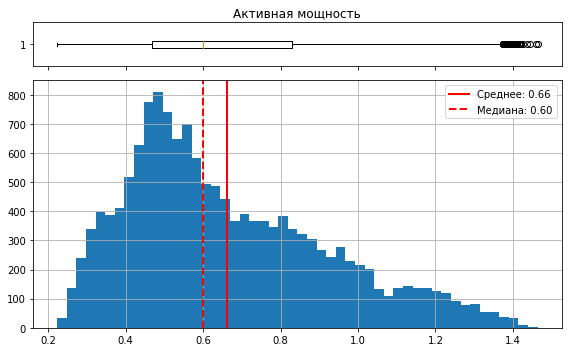

count    14876.000000
mean         0.662752
std          0.258885
min          0.223120
25%          0.467115
50%          0.599587
75%          0.830070
max          1.463773
Name: Активная мощность, dtype: float64


In [58]:
feature_stat(data_arc['Активная мощность'], 'Активная мощность', '')

Активная мощность распределена более-менее равномерно

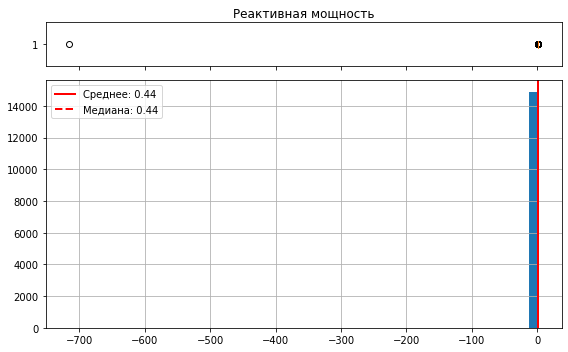

count    14876.000000
mean         0.438986
std          5.873485
min       -715.479924
25%          0.337175
50%          0.441639
75%          0.608201
max          1.270284
Name: Реактивная мощность, dtype: float64


In [59]:
feature_stat(data_arc['Реактивная мощность'], 'Реактивная мощность', '')

Есть аномально низкие значения, оставим, только строки, где мощность больше 0

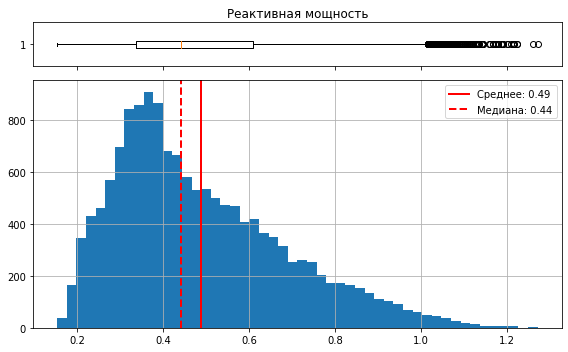

count    14872.000000
mean         0.487112
std          0.197623
min          0.153777
25%          0.337175
50%          0.441667
75%          0.608201
max          1.270284
Name: Реактивная мощность, dtype: float64


In [60]:
data_arc = data_arc.loc[~data_arc['key'].isin(data_arc.loc[data_arc['Реактивная мощность']<0,'key'])]
feature_stat(data_arc['Реактивная мощность'], 'Реактивная мощность', '')

Теперь реактивная мощность распределена равномерно

### `data_bulk` сыпучие материалы

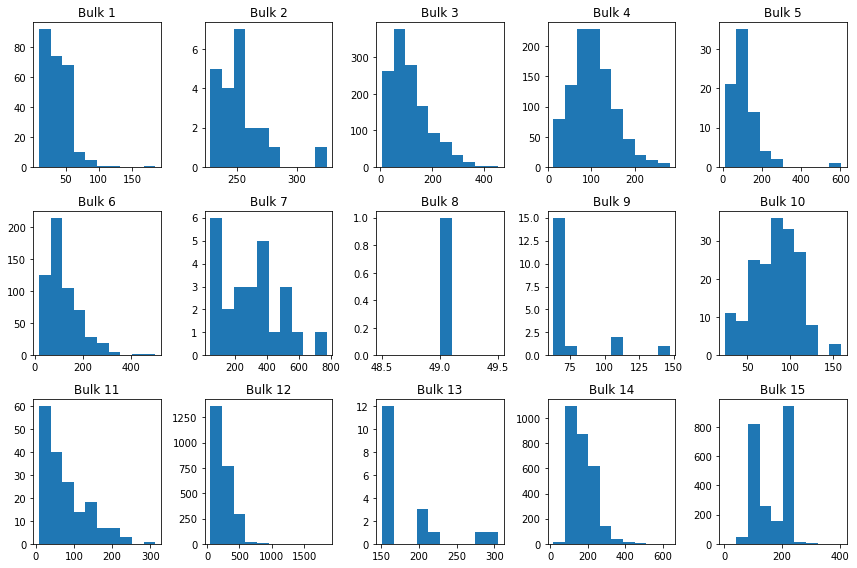

In [61]:
fix, axes = plt.subplots(nrows=3, ncols=5, figsize=(12,8))
i = 0
for i in range(3):
    for j in range(5):
        axes[i, j].hist(data_bulk_volume.loc[data_bulk_volume['Bulk '+str(j+(5*i)+1)]!=0, 'Bulk '+str(j+(5*i)+1)])
        axes[i, j].set_title('Bulk '+str(j+(5*i)+1))
plt.tight_layout()
plt.show()

Данные распределены ненормально, есть выбросы, но возможно они важны в контексте задачи, и о многих материалах в принципе не так много записей, удалять их не будем

Отдельный вопрос вызывает только восьмой материал

In [62]:
data_bulk_volume.loc[data_bulk_volume['Bulk 8']>0]

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
1725,1786,0.0,0.0,123.0,0.0,0.0,0.0,0.0,49.0,147.0,0.0,0.0,0.0,0.0,0.0,0.0


Восьмой материал используется только единожды, следовательно его можно полностью удалить

In [63]:
data_bulk_volume = data_bulk_volume.drop('Bulk 8', axis=1)

Найдём суммарное значение примесей каждого типа

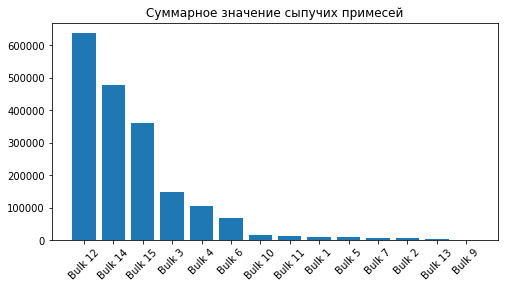

In [64]:
df = pd.DataFrame({'bulk' : data_bulk_volume.columns.drop('key'),
                   'sum' : [sum(data_bulk_volume[x]) for x in data_bulk_volume.columns.drop('key')]})
df = df.sort_values(by='sum', ascending=False)

plt.figure(figsize=(8,4))
plt.bar(df['bulk'], df['sum'])
plt.xticks(rotation=45)
plt.title('Суммарное значение сыпучих примесей')
plt.show()

Больше всего примесей типа 12, 14, 15, 3, 4, 6

Данные о времени добавления примесей не несут важной информации в рамках исследования, рассматривать их не будем

### `data_wire` проволочные материалы

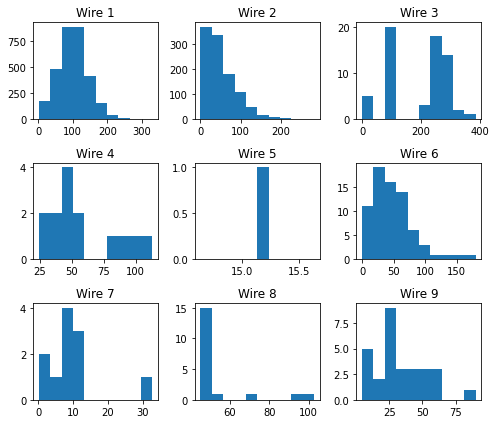

In [65]:
fix, axes = plt.subplots(nrows=3, ncols=3, figsize=(7,6))
i = 0
for i in range(3):
    for j in range(3):
        axes[i, j].hist(data_wire_volume.loc[data_wire_volume['Wire '+str(j+(3*i)+1)]!=0, 'Wire '+str(j+(3*i)+1)])
        axes[i, j].set_title('Wire '+str(j+(3*i)+1))
plt.tight_layout()
plt.show()

Данные распределены ненормально, есть выбросы, но возможно они важны в контексте задачи, и о многих материалах в принципе не так много записей, удалять их не будем

Отдельный вопрос вызывает только пятый материал

In [66]:
data_wire_volume.loc[data_wire_volume['Wire 5']>0]

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
2440,2567,18.30192,0.0,96.288193,0.0,15.132,73.307526,0.0,0.0,0.0


Пятый материал используется только единожды, следовательно его можно полностью удалить

In [67]:
data_wire_volume = data_wire_volume.drop('Wire 5', axis=1)

Найдём суммарное значение примесей каждого типа

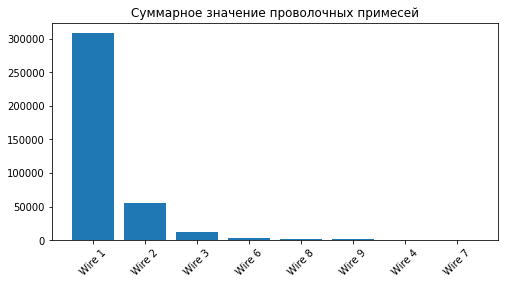

In [68]:
df = pd.DataFrame({'wire' : data_wire_volume.columns.drop('key'),
                   'sum' : [sum(data_wire_volume[x]) for x in data_wire_volume.columns.drop('key')]})
df = df.sort_values(by='sum', ascending=False)

plt.figure(figsize=(8,4))
plt.bar(df['wire'], df['sum'])
plt.xticks(rotation=45)
plt.title('Суммарное значение проволочных примесей')
plt.show()

Больше всего примесей типа 1, 2, 3, 6

Данные о времени добавления примесей не несут важной информации в рамках исследования, рассматривать их не будем

### `data_gas` поддувка сплава газом

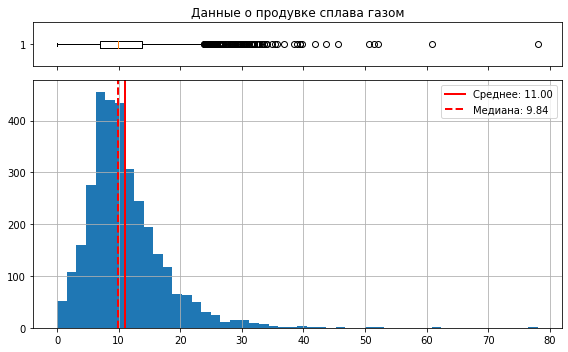

count    3239.000000
mean       11.002062
std         6.220327
min         0.008399
25%         7.043089
50%         9.836267
75%        13.769915
max        77.995040
Name: Газ 1, dtype: float64


In [69]:
feature_stat(data_gas['Газ 1'], 'Данные о продувке сплава газом','')

Удалим выбросы, где значение больше 35

In [70]:
data_gas = data_gas.loc[data_gas['Газ 1']<=35]

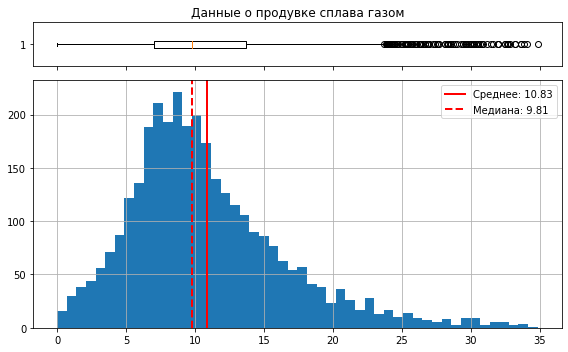

count    3223.000000
mean       10.830778
std         5.688365
min         0.008399
25%         7.024467
50%         9.811060
75%        13.693379
max        34.827057
Name: Газ 1, dtype: float64


In [71]:
feature_stat(data_gas['Газ 1'], 'Данные о продувке сплава газом','')

### `data_temp` измерения температуры

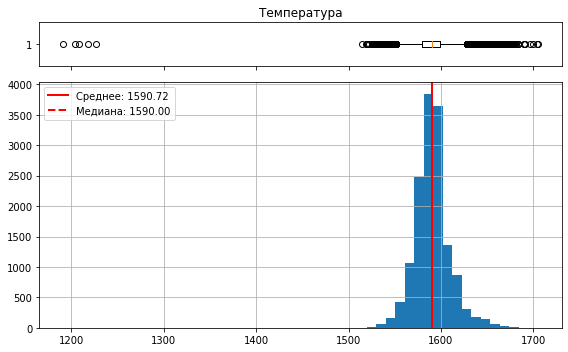

count    14665.000000
mean      1590.722741
std         20.394381
min       1191.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: Температура, dtype: float64


In [72]:
feature_stat(data_temp['Температура'].dropna(),'Температура','')

Температура плавления 1400 градусов, следовательно, всё что ниже - некачественные данные, стоит удалить

In [73]:
bad_keys = data_temp.loc[data_temp['Температура']<1400,'key'].unique()

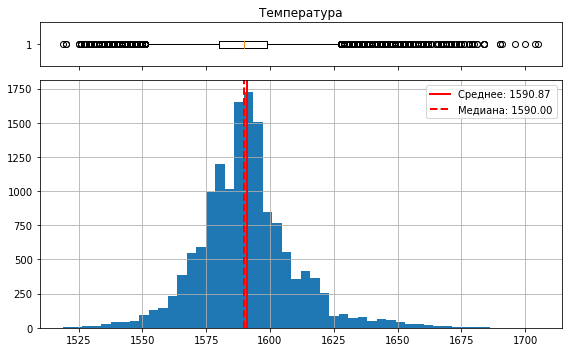

count    14643.000000
mean      1590.865055
std         19.122102
min       1519.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: Температура, dtype: float64


In [74]:
feature_stat(data_temp.loc[~data_temp['key'].isin(bad_keys), 'Температура'].dropna(),'Температура','')

Нас из всех замеров, интересуют только начальная температура и конечная, создадим отдельный датафрейм

In [75]:
data_temp_res = data_temp.drop_duplicates(subset=['key'], keep='first')
data_temp_res.columns = ['key', 'Время замера', 'Начальная температура']

In [76]:
data_temp_res['Конечная температура'] = data_temp.drop_duplicates(subset=['key'], keep='last')['Температура'].values

/tmp/ipykernel_31/273612794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_temp_res['Конечная температура'] = data_temp.drop_duplicates(subset=['key'], keep='last')['Температура'].values


In [77]:
data_temp_res

,key,Время замера,Начальная температура,Конечная температура
0,1,2019-05-03 11:02:04,1571.0,1613.0
6,2,2019-05-03 11:34:04,1581.0,1602.0
11,3,2019-05-03 12:06:44,1596.0,1599.0
17,4,2019-05-03 12:39:27,1601.0,1625.0
22,5,2019-05-03 13:11:03,1576.0,1602.0
...,...,...,...,...
18061,3237,2019-09-06 11:31:15,1569.0,NaN
18067,3238,2019-09-06 12:16:15,1584.0,NaN
18071,3239,2019-09-06 14:16:50,1598.0,NaN
18080,3240,2019-09-06 15:25:21,1617.0,NaN


Удаляем строки, где есть пропуски и в которых расположены записи о партиях, в которых были замеры меньше 1400

In [78]:
data_temp_res = data_temp_res.loc[~data_temp_res['key'].isin(bad_keys)].dropna()

### Вывод

- Пропуски в `data_wire_volume` и `data_bulk_volume` заменены ну 0
- В `data_arc` столбцы `Начало нагрева дугой`, `Конец нагрева дугой` приведены к типу datetime
- В таблице `data_arc` удалены аномалии в реактивной мощности (<0)
- В сыпучих материалах удалён восьмой материал, так как он использовался лишь 1 раз
- В проволочных материалах удалён пятый материал, так как он использовался лишь 1 раз
- В `data_temp` удалены значения меньше 1400 (температура плавления), оставлены только начальная и конечная температура партии, после чего удалены пропуски

## Объединение данных

Создадим итоговую таблицу, в ней будут следующие столбцы:
- `key` - номер партии
- `Время нагрева` - время нагрева партии без учёта простоев
- `Полная мощность` - $\sum\sqrt{\text{активная мощность}^2+\text{реактивная мощность}^2}$
- `Действительная энергия` - $\sum(\text{полная мощность}\cdot\text{длительность нагрева})$
- \[`Bulk 1`...`Bulk 15`\] - суммарный объём подаваемого сыпучего материала
- \[`Wire 1`...`Wire 9`\] - суммарный объём подаваемого проволочного материала
- `Газ` - объём подаваемого газа
- `Начальная температура`
- `Конечная температура`

In [79]:
data_arc['Полная мощность'] = np.sqrt(data_arc['Активная мощность']**2 + data_arc['Реактивная мощность']**2)
data_arc['Время нагрева'] = (data_arc['Конец нагрева дугой'] - data_arc['Начало нагрева дугой']).dt.total_seconds()
data_arc['Действительная энергия'] = data_arc['Полная мощность'] * data_arc['Время нагрева']
data_res = data_arc[['key', 'Полная мощность', 'Время нагрева', 'Действительная энергия']].groupby('key').agg('sum')
data_res = data_res.merge(data_gas, on='key', how='inner')
data_res = data_res.merge(data_temp_res.drop('Время замера', axis=1), on='key', how='inner')
data_res = data_res.merge(data_bulk_volume, on='key', how='inner')
data_res = data_res.merge(data_wire_volume, on='key', how='inner')

In [80]:
data_res

,key,Полная мощность,Время нагрева,Действительная энергия,Газ 1,Начальная температура,Конечная температура,Bulk 1,Bulk 2,Bulk 3,...,Bulk 14,Bulk 15,Wire 1,Wire 2,Wire 3,Wire 4,Wire 6,Wire 7,Wire 8,Wire 9
0,1,3.718736,1098.0,770.282114,29.749986,1571.0,1613.0,0.0,0.0,0.0,...,150.0,154.0,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2.588349,811.0,481.760005,12.555561,1581.0,1602.0,0.0,0.0,0.0,...,149.0,154.0,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
2,3,5.019223,655.0,722.837668,28.554793,1596.0,1599.0,0.0,0.0,0.0,...,152.0,153.0,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
3,4,3.400038,741.0,683.455597,18.841219,1601.0,1625.0,0.0,0.0,0.0,...,153.0,154.0,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2.816980,869.0,512.169934,5.413692,1576.0,1602.0,0.0,0.0,0.0,...,151.0,152.0,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,2495,3.868721,723.0,694.177326,7.125735,1570.0,1591.0,0.0,0.0,21.0,...,129.0,223.0,89.150879,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
2306,2496,5.070316,940.0,815.818538,9.412616,1554.0,1591.0,0.0,0.0,0.0,...,129.0,226.0,114.179527,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
2307,2497,4.360918,569.0,823.020520,6.271699,1571.0,1589.0,0.0,0.0,0.0,...,124.0,226.0,94.086723,9.04800,0.0,0.0,0.0,0.0,0.0,0.0
2308,2498,3.909917,750.0,581.810739,14.953657,1591.0,1594.0,0.0,0.0,90.0,...,129.0,207.0,118.110717,0.00000,0.0,0.0,0.0,0.0,0.0,0.0


## Исследовательский анализ и предобработка данных объединённого датафрейма

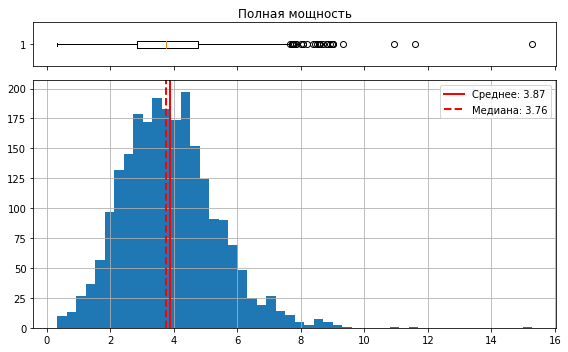

count    2310.000000
mean        3.872393
std         1.481080
min         0.331897
25%         2.845093
50%         3.763768
75%         4.758179
max        15.288271
Name: Полная мощность, dtype: float64


In [81]:
feature_stat(data_res['Полная мощность'],'Полная мощность', '')

Удалим значения больше 10

In [82]:
data_res = data_res.loc[data_res['Полная мощность']<=10]

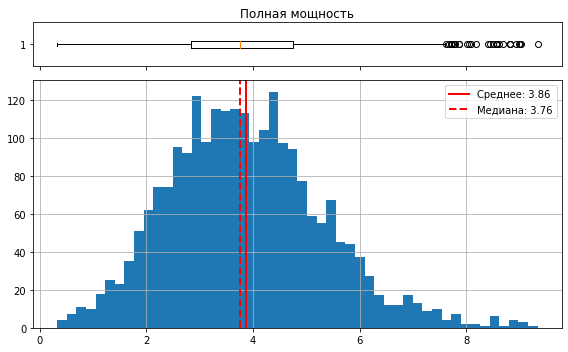

count    2307.000000
mean        3.861044
std         1.446526
min         0.331897
25%         2.843625
50%         3.761492
75%         4.747815
max         9.335721
Name: Полная мощность, dtype: float64


In [83]:
feature_stat(data_res['Полная мощность'],'Полная мощность', '')

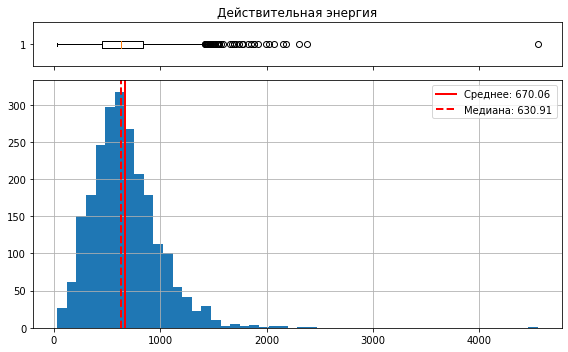

count    2325.000000
mean      670.060566
std       319.565380
min        33.430208
25%       457.872635
50%       630.913482
75%       841.644330
max      4546.405812
Name: Действительная энергия, dtype: float64


In [29]:
feature_stat(data_res['Действительная энергия'],'Действительная энергия', '')

Удалим значения больше 1750

In [86]:
data_res = data_res.loc[data_res['Действительная энергия']<=1750]

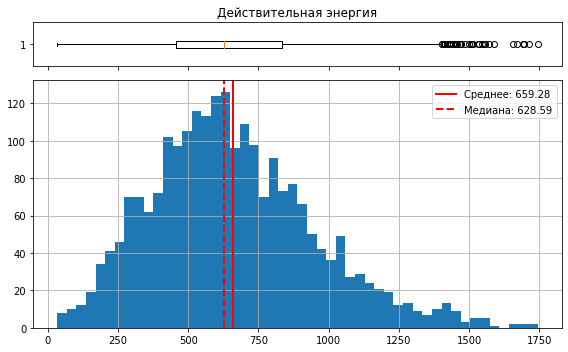

count    2297.000000
mean      659.282104
std       290.849503
min        33.430208
25%       455.037878
50%       628.589633
75%       834.099402
max      1743.739733
Name: Действительная энергия, dtype: float64


In [87]:
feature_stat(data_res['Действительная энергия'],'Действительная энергия', '')

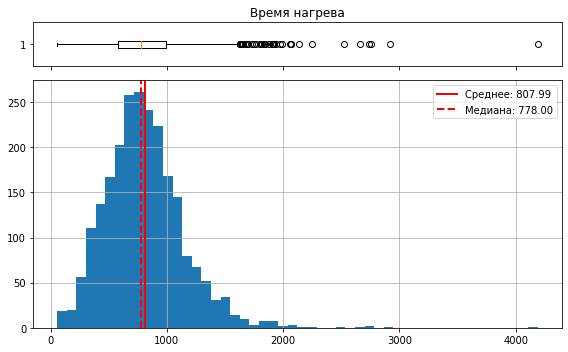

count    2325.000000
mean      807.988387
std       340.888430
min        57.000000
25%       581.000000
50%       778.000000
75%       993.000000
max      4189.000000
Name: Время нагрева, dtype: float64


In [30]:
feature_stat(data_res['Время нагрева'],'Время нагрева', '')

Удалим значения больше 2000

In [88]:
data_res = data_res.loc[data_res['Время нагрева']<=2000]

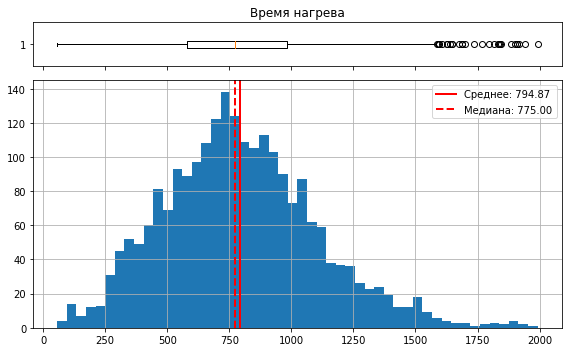

count    2294.000000
mean      794.871840
std       310.251108
min        57.000000
25%       580.000000
50%       775.000000
75%       982.000000
max      1992.000000
Name: Время нагрева, dtype: float64


In [89]:
feature_stat(data_res['Время нагрева'],'Время нагрева', '')

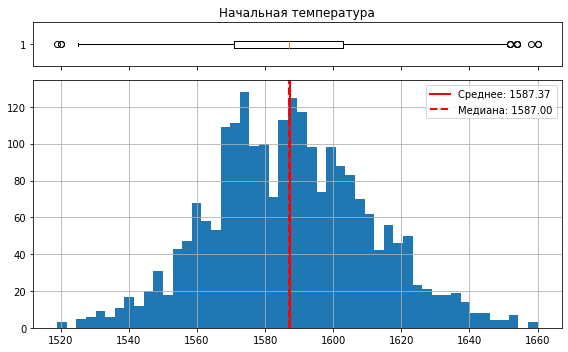

count    2294.000000
mean     1587.367044
std        23.448777
min      1519.000000
25%      1571.000000
50%      1587.000000
75%      1603.000000
max      1660.000000
Name: Начальная температура, dtype: float64


In [90]:
feature_stat(data_res['Начальная температура'],'Начальная температура', '')

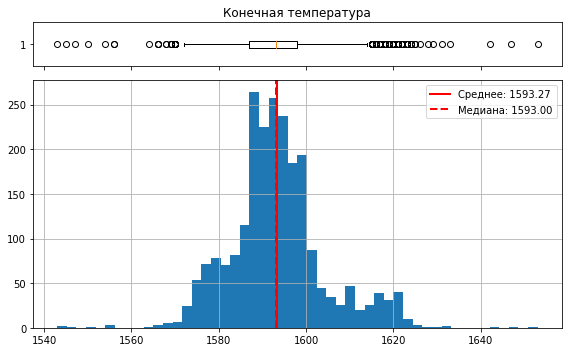

count    2294.000000
mean     1593.273322
std        11.014434
min      1543.000000
25%      1587.000000
50%      1593.000000
75%      1598.000000
max      1653.000000
Name: Конечная температура, dtype: float64


In [91]:
feature_stat(data_res['Конечная температура'],'Конечная температура', '')

## Корреляционный анализ

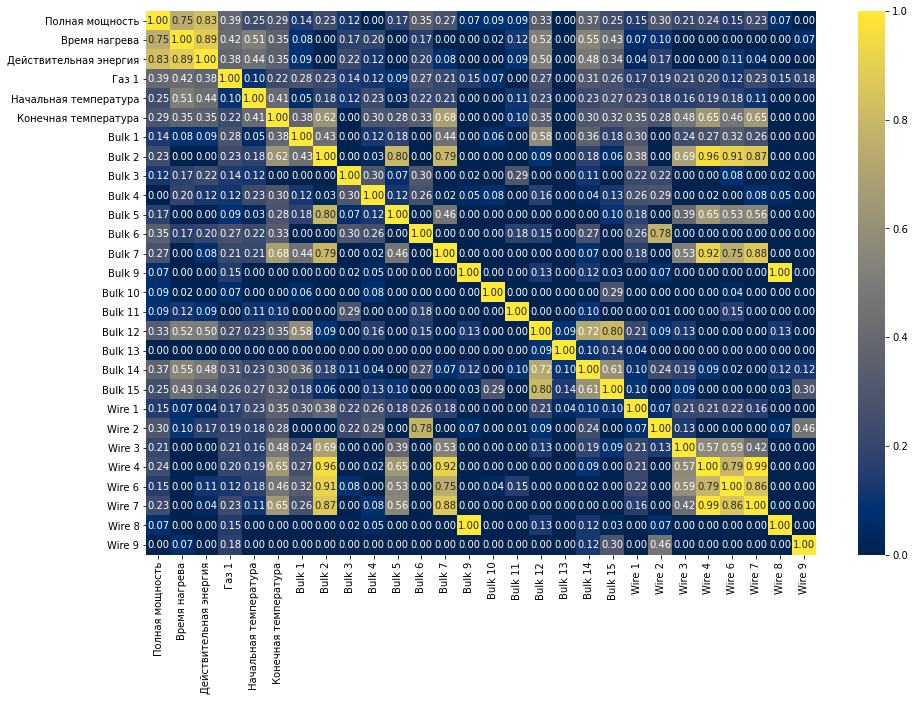

In [93]:
plt.figure(figsize=(15, 10))
sns.heatmap(data_res.drop(['key'], axis=1).phik_matrix(interval_cols= data_res.select_dtypes(include='number').columns),
            annot=True, fmt='.2f', cmap='cividis')
plt.show()

Видно мультиколлинеарность, для избавления от неё удалим признаки `Bulk 7`, `Bulk 2`, `Bulk 9`, `Wire 4`

In [94]:
data_res = data_res.drop(['Bulk 7', 'Bulk 2', 'Bulk 9', 'Wire 4'], axis=1)

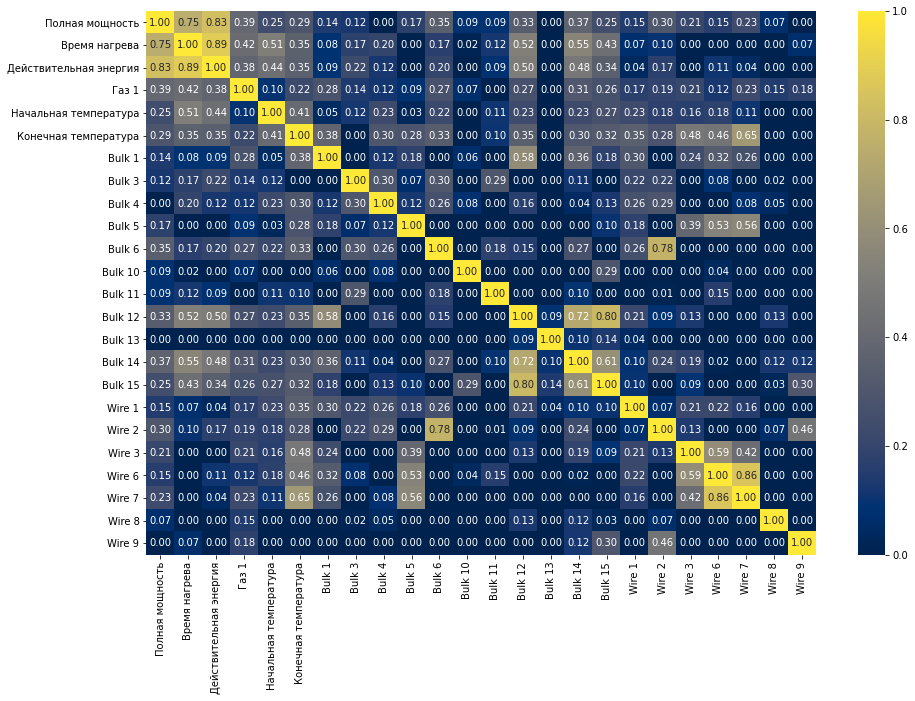

In [95]:
plt.figure(figsize=(15, 10))
sns.heatmap(data_res.drop(['key'], axis=1).phik_matrix(interval_cols= data_res.select_dtypes(include='number').columns),
            annot=True, fmt='.2f', cmap='cividis')
plt.show()

## Подготовка данных

Разобьём выборку на обучающую и тестовую

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    data_res.drop(['Конечная температура', 'key'], axis=1),
    data_res['Конечная температура'],
    random_state=RANDOM_STATE
)

Признаки отмасштабируем с помощью MinMaxScaler

In [97]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

## Обучение моделей

In [100]:
pipe = Pipeline([
    ('models', LinearRegression())
])

param_grid=[
    #словарь для LinearRegression()
    {
        'models' : [LinearRegression()],
         'models__fit_intercept' : [True, False]
    },
    #словарь для DecisionTreeRegressor()
    {
        'models' : [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth' : range(10, 100, 20),
        'models__min_samples_leaf' : range(1, 10),
        'models__min_samples_split' : range(2, 10)
    },
    #словарь для CatBoostRegressor()
    {
        'models': [CatBoostRegressor(random_state=RANDOM_STATE, verbose=False)],
        'models__iterations': [100, 300, 500],
        'models__learning_rate': [0.01, 0.05, 0.1],
        'models__depth': [4, 6, 8, 10],
        'models__l2_leaf_reg': [1, 3, 5, 7]
    }
]

In [101]:
randomized_search = RandomizedSearchCV(
    pipe,
    param_grid,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

randomized_search.fit(X_train, y_train)

RandomizedSearchCV(estimator=Pipeline(steps=[('models', LinearRegression())]),
                   n_jobs=-1,
                   param_distributions=[{'models': [LinearRegression()],
                                         'models__fit_intercept': [True,
                                                                   False]},
                                        {'models': [DecisionTreeRegressor(random_state=310326)],
                                         'models__max_depth': range(10, 100, 20),
                                         'models__min_samples_leaf': range(1, 10),
                                         'models__min_samples_split': range(2, 10)},
                                        {'models': [<catboost.core.CatBoostRegressor object at 0x7f72b7117e50>],
                                         'models__depth': [4, 6, 8, 10],
                                         'models__iterations': [100, 300, 500],
                                         'models__l2_lea

In [102]:
print("Лучшая модель:")
print(f"Тип модели: {type(randomized_search.best_estimator_.named_steps['models']).__name__}")
print(f"\nЛучшие гиперпараметры:")
for param, value in randomized_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nЛучший MAE на тренировочной выборке: {-randomized_search.best_score_:.4f}")
print(f"Лучший MAE на тестовой выборке: {mean_absolute_error(y_test, randomized_search.best_estimator_.predict(X_test)):.4f}")

Лучшая модель:
Тип модели: CatBoostRegressor

Лучшие гиперпараметры:
  models__learning_rate: 0.05
  models__l2_leaf_reg: 7
  models__iterations: 500
  models__depth: 10
  models: <catboost.core.CatBoostRegressor object at 0x7f72b7117e50>

Лучший MAE на тренировочной выборке: 6.1431
Лучший MAE на тестовой выборке: 6.1003


## Важность признаков

In [103]:
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': randomized_search.best_estimator_.named_steps['models'].get_feature_importance()
}).sort_values('Важность', ascending=True)

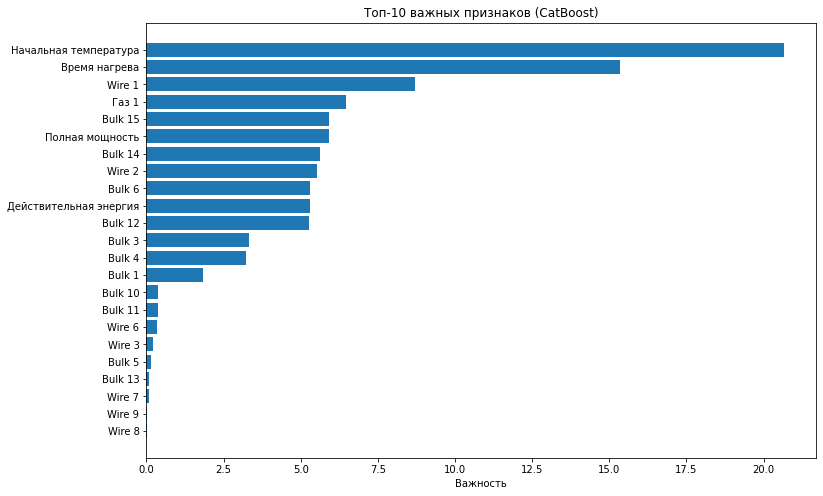

In [104]:
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Признак'], feature_importance['Важность'])
plt.xlabel('Важность')
plt.title('Топ-10 важных признаков (CatBoost)')
plt.show()

Самые важные признаки - это `Начальная температура`, `Время нагрева`, `Wire 1`, `Действительная энергия`

Интересно, что самые важные материалы примесей совпадают с теми, что имеют самый большой суммарный объём

## Вывод

По полученным данным была проведена следующая работа

**Исследовательский анализ и предобработка данных**

- Пропуски в `data_wire_volume` и `data_bulk_volume` заменены ну 0
- В `data_arc` столбцы `Начало нагрева дугой`, `Конец нагрева дугой` приведены к типу datetime
- В таблице `data_arc` удалены аномалии в реактивной мощности (<0)
- В сыпучих материалах удалён восьмой материал, так как он использовался лишь 1 раз
- В проволочных материалах удалён пятый материал, так как он использовался лишь 1 раз
- В `data_temp` удалены значения меньше 1400 (температура плавления), оставлены только начальная и конечная температура партии, после чего удалены пропуски

**Объединение данных**

Была создана итоговая таблица со следующими слобцами:
- `key` - номер партии
- `Время нагрева` - время нагрева партии без учёта простоев
- `Полная мощность` - $\sum\sqrt{\text{активная мощность}^2+\text{реактивная мощность}^2}$
- `Действительная энергия` - $\sum(\text{полная мощность}\cdot\text{длительность нагрева})$
- \[`Bulk 1`...`Bulk 15`\] - суммарный объём подаваемого сыпучего материала
- \[`Wire 1`...`Wire 9`\] - суммарный объём подаваемого проволочного материала
- `Газ` - объём подаваемого газа
- `Начальная температура`
- `Конечная температура`

**Исследовательский анализ и предобработка данных объединённого датафрейма**

Из новых признаков удалены выбросы

**Корреляционный анализ**

Была выявлена мультиколлинеарность, для устранения которой были удалены признаки `Bulk 7`, `Bulk 2`, `Bulk 9`, `Wire 4`

**Подготовка данных**

Данные разбиты на обучающую и тестовую выборки и отмасштабированы

**Обучение моделей**

Были обучены три модели, лучшей оказалась модель со следующими параметрами:

```
Тип модели: CatBoostRegressor

Лучшие гиперпараметры:
  models__learning_rate: 0.05
  models__l2_leaf_reg: 7
  models__iterations: 500
  models__depth: 10
  models: <catboost.core.CatBoostRegressor object at 0x7f72b7117e50>

Лучший MAE на тренировочной выборке: 6.1431
Лучший MAE на тестовой выборке: 6.1003
```

**Важность признаков**

Самые важные признаки - это `Начальная температура`, `Время нагрева`, `Wire 1`, `Действительная энергия`

Интересно, что самые важные материалы примесей совпадают с теми, что имеют самый большой суммарный объём

**Рекомендации заказчику**

Во многих партиях после первого замера температуры данные отсутствуют. Рекомендуется проверить оборудование, замеряющее температуру, возможно оно повреждено.